In [1]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/ukb_phasing')

In [ ]:
library(data.table)
library(ggplot2)
library(Hmisc)

In [3]:
args <- list(
    #in_prefix = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr"
    in_prefix = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/mt/annotated/ukb_eur_wes_200k_annot_chr"
)


In [4]:
files <- list.files(dirname(args$in_prefix), pattern = basename(args$in_prefix), full.names = TRUE)
files <- files[grepl(".trio",files)]

In [5]:
lst <- lapply(files, function(f) {
    d <- suppressWarnings(fread(f)) 
    d$CHR <- stringr::str_extract(f, "chr[0-9]+")
    return(d)
})

In [126]:
d <- do.call(rbind, lst)

In [127]:
colnames(d) <- c("trio","F",'M','O',"tested","mend","ser",'serpct',"chr")

In [128]:
errors <- aggregate(ser ~ chr, data = d, FUN = sum)
mend <- aggregate(mend ~ chr, data = d, FUN = sum)
tested <- aggregate(tested ~ chr, data = d, FUN = sum)

In [129]:
counts <- data.frame(errors)
counts$mend <- mend$mend
counts$tested <- tested$tested

In [130]:
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$ser[i], counts$tested[i]) * 100))

In [131]:
final <- cbind(counts, counts_ci)

In [140]:
(121364 / 871347) * 483

[1] 67.27379

In [136]:
final

chr,ser,mend,tested,pointest,lower,upper
<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
chr1,1,22,121364,0.0008239676,4.226401e-05,0.004667570
chr10,3,3,54300,0.0055248619,1.878969e-03,0.016243982
chr11,5,9,84613,0.0059092574,2.524107e-03,0.013833699
chr12,9,15,62906,0.0143070613,7.527398e-03,0.027191270
chr13,0,12,22009,0.0000000000,0.000000e+00,0.017450990
chr14,3,10,40936,0.0073285128,2.492386e-03,0.021546444
chr15,3,10,40217,0.0074595320,2.536946e-03,0.021931610
chr16,9,21,62790,0.0143334926,7.541304e-03,0.027241500
chr17,8,7,74000,0.0108108108,5.478205e-03,0.021333185


In [137]:
final_geno

chr,ser,mend,tested,pointest,lower,upper
<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
chr1,483,1519,871347,0.05543142,0.05070463,0.06059858
chr10,316,980,538679,0.05866202,0.05254241,0.06549392
chr11,328,971,578568,0.05669169,0.05088087,0.06316572
chr12,303,1004,535867,0.05654388,0.05052700,0.06327682
chr13,240,793,354984,0.06760868,0.05958138,0.07671666
chr14,194,622,354197,0.05477178,0.04758926,0.06303765
chr15,227,615,359647,0.06311745,0.05542537,0.07187628
chr16,199,627,422085,0.04714690,0.04103684,0.05416622
chr17,218,558,414646,0.05257497,0.04604515,0.06003025


In [132]:
rownames(final) <- NULL
colnames(final) <- tolower(colnames(final))

In [133]:
#final_geno <- final

In [134]:
final$chr <- factor(final$chr, levels = paste0("chr",1:22))

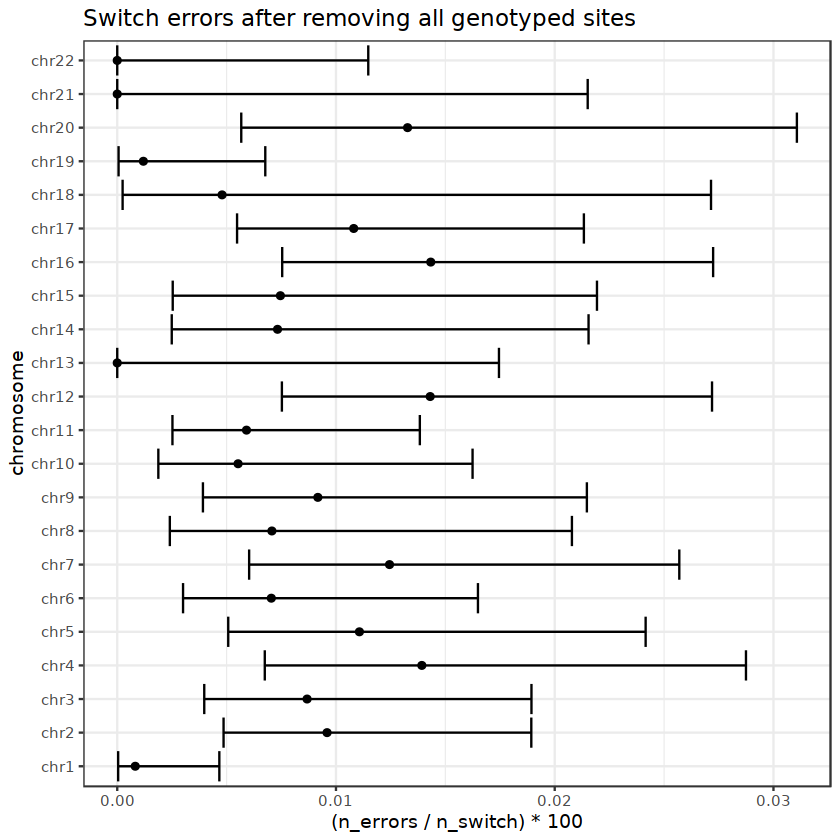

In [135]:
main <- "Switch errors after removing all genotyped sites"
ggplot(final, aes(y=chr, x=pointest, xmax=upper, xmin=lower)) +
    geom_point() +
    geom_errorbar() +
    xlab("(n_errors / n_switch) * 100") +
    ylab("chromosome") +
    theme_bw() +
    ggtitle(main)

In [141]:
args <- list(
    in_prefix = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr"
    #in_prefix = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/mt/annotated/ukb_eur_wes_200k_annot_chr"
)


In [161]:
files <- list.files(dirname(args$in_prefix), pattern = basename(args$in_prefix), full.names = TRUE)
files <- files[grepl(".txt",files)]

In [162]:
lst <- lapply(files, function(f) {
    d <- suppressWarnings(fread(f)) 
    d$CHR <- stringr::str_extract(f, "chr[0-9]+")
    return(d)
})

In [167]:
d <- do.call(rbind, lst)

In [168]:
d$locus <- paste0(d$CHR,":",d$POS)

In [169]:
variants <- fread("/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list")

In [170]:
d$in_wes <- d$locus %in% variants$locus

In [200]:
counts <- aggregate(switches ~ wes + CHR, data = d, FUN = sum)

In [193]:
tested <- aggregate(switches ~ wes + CHR, data = d, FUN = length)

In [201]:
counts$tested <- tested$switches

In [207]:
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i]) * 100))

In [225]:
counts

wes,chr,switches,tested,pointest,lower,upper
<lgl>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>
FALSE,chr1,455,685965,0.066329915,0.060510478,0.07270861
TRUE,chr1,28,185382,0.015103948,0.010450629,0.02182878
FALSE,chr10,295,457438,0.064489614,0.057540283,0.07227763
TRUE,chr10,21,81241,0.025849017,0.016908278,0.03951556
FALSE,chr11,290,445905,0.065036275,0.057971347,0.07296157
TRUE,chr11,38,132663,0.028644008,0.020870843,0.03931108
FALSE,chr12,269,441794,0.060888106,0.054035431,0.06860923
TRUE,chr12,34,94073,0.036142145,0.025866122,0.05049854
FALSE,chr13,234,322349,0.072592128,0.063870523,0.08250370


In [209]:
counts <- cbind(counts, counts_ci)

In [212]:
rownames(counts) <- NULL
colnames(counts) <- tolower(colnames(counts))
counts$chr <- factor(counts$chr, levels = paste0("chr",1:22))


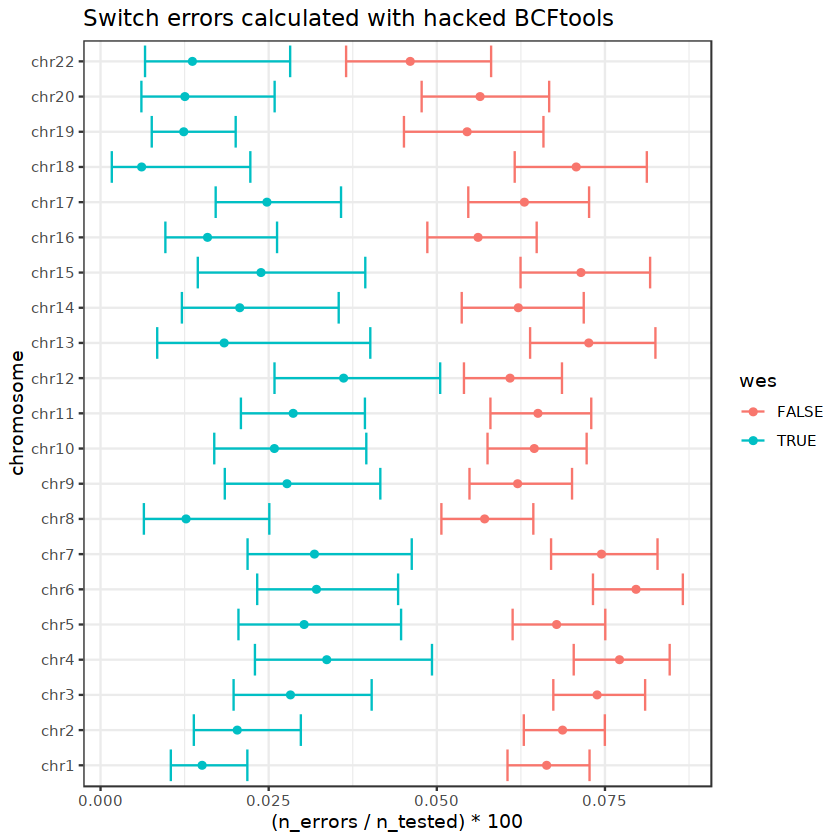

In [224]:
main <- "Switch errors calculated with hacked BCFtools"
ggplot(counts, aes(y=chr, x=pointest, xmax=upper, xmin=lower, color = wes)) +
    geom_point() +
    geom_errorbar() +
    xlab("(n_errors / n_tested) * 100") +
    ylab("chromosome") +
    theme_bw() +
    ggtitle(main)

In [219]:
dwes <- d[d$CHR == "chr1"]
dwes$cumsum <- cumsum(dwes$switches)

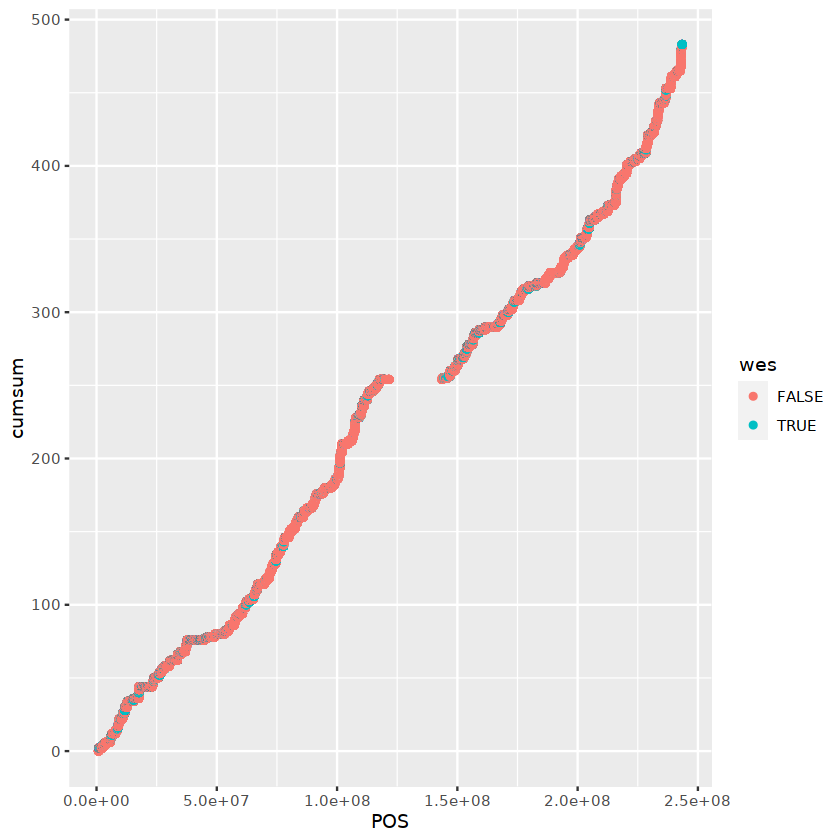

In [223]:
ggplot(dwes, aes(x=POS, y=cumsum, color = wes)) +
       geom_point()

In [ ]:
args <- list(
    #in_prefix = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes_union_calls/ligated/new/ukb_eur_wes_union_calls_200k_chr"
    in_prefix = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/mt/annotated/ukb_eur_wes_200k_annot_chr"
)


# Differential SER evaluation

In [2]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/')
library(data.table)

In [72]:
d4 <- fread('data/phased/wes_union_calls/200k/shapeit4/with_parents/ukb_eur_wes_union_calls_200k_chr21.txt')
d5 <- fread('data/phased/wes_union_calls/200k/shapeit5/parents/ukb_wes_union_calls_200k_shapeit5_parents_chr21.txt')

In [73]:
# files almost have same length
print(nrow(d4)); print(nrow(d5)); print(nrow(d4)-nrow(d5))

[1] 173024
[1] 166826
[1] 6198


In [74]:
max(d4$POS); max(d5$POS, na.rm = TRUE); sum(is.na(d5$POS))

[1] 46679698

[1] 46674891

[1] 0

In [75]:
d4$ID <- paste0(d4$CHR, ":", d4$POS, ":",d4$REF, ":", d4$ALT)
d4$ID_flip <-  paste0(d4$CHR, ":", d4$POS, ":",d4$ALT, ":", d4$REF)
d5$ID <- paste0(d5$CHR, ":", d5$POS, ":",d5$REF, ":", d5$ALT)
d5$ID_flip <-  paste0(d5$CHR, ":", d5$POS, ":",d5$ALT, ":", d5$REF)

In [76]:
id4_uniq <- unique(d4$ID)
id4_flip_uniq <- unique(d4$ID_flip)
id5_uniq <- unique(d5$ID)
id5_flip_uniq <- unique(d5$ID_flip)

In [77]:
# How many unqiue alleles are in D4 versus D5?
print(length(id4_uniq)); print(length(id5_uniq))


[1] 11541
[1] 11161


In [51]:
# What alleles are different?
diff <- unique(setdiff(id4_uniq, id5_uniq))
overlap <- unique(intersect(id4_uniq, id5_uniq))
length(diff); length(overlap)

[1] 9650

[1] 1891

In [52]:
# What alleles are different if we flip over all D5 (ireggardless of strand)?
length(unique(setdiff(id4_uniq, id5_flip_uniq)))
length(unique(intersect(id4_uniq, id5_flip_uniq)))

[1] 1893

[1] 9648

In [78]:
# Are there duplicate alleles in S4
d4_uniq <- data.frame(id4_uniq, id4_flip_uniq)
d4_uniq$id_d4 <- d4_uniq$id4_uniq %in% d4$ID
d4_uniq$id_flip_d4 <- d4_uniq$id4_flip_uniq %in% d4$ID
n4 <- sum(rowSums(d4_uniq[,3:4]) == 2)
print(paste(n4, 'alleles exists as flipped and unflipped in s4'))

[1] "754 alleles exists as flipped and unflipped in s4"


In [79]:
# Are there duplicate alleles in S5
d5_uniq <- data.frame(id5_uniq, id5_flip_uniq)
d5_uniq$id_d5 <- d5_uniq$id5_uniq %in% d5$ID
d5_uniq$id_flip_d5 <- d5_uniq$id5_flip_uniq %in% d5$ID
n5 <- sum(rowSums(d5_uniq[,3:4]) == 2)
print(paste(n5, 'alleles exists as flipped and unflipped in s5'))

[1] "8 alleles exists as flipped and unflipped in s5"


In [80]:
# Let's remove the 754 alleles that exists in the flipped version
d4_clean <- d4[! (d4$ID %in% d4_uniq$id4_flip_uniq),]

# now it looks like they are matching!
nrow(d4_clean); nrow(d5) 

[1] 160807

[1] 166826

In [81]:
# let's check indiiual variant counts
id4_clean <- unique(d4_clean$ID)
id5 <- unique(d5$ID)
length(id4_clean); length(id5)

# roughly the same number of sites.

[1] 10787

[1] 11161

In [82]:
# what sites are different and why?
s4_super_overlap <- sum(id4_uniq %in% id5_uniq | id4_flip_uniq %in% id5_uniq) 
s5_super_overlap <- sum(id5_uniq %in% id4_uniq | id5_flip_uniq %in% id4_uniq) 
paste(s4_super_overlap, '/', length(id4_uniq), ' of sites in S4 are in S5')
paste(s5_super_overlap, '/', length(id5_uniq), ' of sites in S4 are in S5')


[1] "11531 / 11541  of sites in S4 are in S5"

[1] "11159 / 11161  of sites in S4 are in S5"

In [6]:
# there are 20K unique variants in S4 file but only 5K unique variants in S5 file.


[1] 20806
[1] 5663


In [7]:
print(sum(id5_uniq %in% id4_uniq)); print(sum(id5_uniq %in% id4_flip_uniq))

[1] 833
[1] 4997


In [24]:
bad_boys <- id5_uniq[id5_uniq %in% id4_uniq & id5_uniq %in% id4_flip_uniq]
length(bad_boys)
bad_boys[1]

[1] 169

[1] "chr20:145514:G:GCAAA"

In [34]:
head(d5[d5$ID %in% "chr20:145514:G:GCAAA"])
head(d5[d5$ID_flip %in% "chr20:145514:G:GCAAA"])
head(d4[d4$ID %in% "chr20:145514:G:GCAAA"])
head(d4[d4$ID_flip %in% "chr20:145514:G:GCAAA"])

ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches,ID_flip
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.15559,0.84441,337146,399268,0.925354,3,234,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.15559,0.84441,337146,399268,0.925354,4,234,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.15559,0.84441,337146,399268,0.925354,5,234,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.15559,0.84441,337146,399268,0.925354,7,234,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.15559,0.84441,337146,399268,0.925354,10,234,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.15559,0.84441,337146,399268,0.925354,12,234,0,0,chr20:145514:GCAAA:G


ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches,ID_flip
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155544,0.155544,62103,399262,0.918568,3,235,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155544,0.155544,62103,399262,0.918568,4,235,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155544,0.155544,62103,399262,0.918568,5,235,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155544,0.155544,62103,399262,0.918568,7,235,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155544,0.155544,62103,399262,0.918568,10,235,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155544,0.155544,62103,399262,0.918568,12,235,0,0,chr20:145514:G:GCAAA


ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches,ID_flip
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.155587,0.844413,337191,399320,0.932126,3,148,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.155587,0.844413,337191,399320,0.932126,4,148,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.155587,0.844413,337191,399320,0.932126,5,148,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.155587,0.844413,337191,399320,0.932126,7,148,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.155587,0.844413,337191,399320,0.932126,10,148,0,0,chr20:145514:GCAAA:G
chr20:145514:G:GCAAA,chr20,145514,G,GCAAA,0.155587,0.844413,337191,399320,0.932126,12,148,0,0,chr20:145514:GCAAA:G


ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches,ID_flip
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155547,0.155547,62112,399314,0.89832,3,149,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155547,0.155547,62112,399314,0.89832,4,149,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155547,0.155547,62112,399314,0.89832,5,149,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155547,0.155547,62112,399314,0.89832,7,149,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155547,0.155547,62112,399314,0.89832,10,149,0,0,chr20:145514:G:GCAAA
chr20:145514:GCAAA:G,chr20,145514,GCAAA,G,0.155547,0.155547,62112,399314,0.89832,12,149,0,0,chr20:145514:G:GCAAA


In [8]:
nooverlap <- d4[ ! ((d4$ID_flip %in% id5_uniq) | (d4$ID %in% id5_uniq)),]

In [9]:
# but there are 15k variants in the S4 file that is not present in the S5 file
length(unique(nooverlap$ID))

[1] 14986

In [10]:
sum(d5$ID %in% d4$ID)

[1] 11334

In [11]:
sum(d5$ID %in% d4$ID_flip)

[1] 80238

In [12]:
nrow(d4); nrow(d5)

[1] 303373

[1] 291220

In [13]:
cat_grep <- function(f, g) fread(cmd = paste("cat",f,"| grep", g))

In [15]:
d4t <- cat_grep('data/phased/wes_union_calls/200k/shapeit4/with_parents/ukb_eur_wes_union_calls_200k_chr20.trio', "TRIO")
d5t <- cat_grep('data/phased/wes_union_calls/200k/shapeit5/parents/ukb_wes_union_calls_200k_shapeit5_parents_chr20.trio', "TRIO")

In [17]:
head(d4t); head(d5t)

# TRIO,[2]Father,[3]Mother,[4]Child,[5]nTested,[6]nMendelian Errors,[7]nSwitch,[8]nSwitch (%)
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
TRIO,3198027,1536567,1079534,3322,12,9,0.27
TRIO,2555570,3345127,2503898,3140,5,8,0.25
TRIO,2065411,4283321,2291527,3114,0,2,0.06
TRIO,3050457,1393856,3620172,3304,4,8,0.24
TRIO,3050457,1393856,4408960,3329,2,5,0.15
TRIO,2099849,2503352,1144246,2980,0,4,0.13


# TRIO,[2]Father,[3]Mother,[4]Child,[5]nTested,[6]nMendelian Errors,[7]nSwitch,[8]nSwitch (%)
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
TRIO,3198027,1536567,1079534,3192,12,10,0.31
TRIO,2555570,3345127,2503898,3007,5,8,0.27
TRIO,2065411,4283321,2291527,2984,0,5,0.17
TRIO,3050457,1393856,3620172,3164,4,6,0.19
TRIO,3050457,1393856,4408960,3189,2,6,0.19
TRIO,2099849,2503352,1144246,2870,0,2,0.07


In [14]:
d <- fread("data/")

ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>
,,NA,,,NA,NA,NA,NA,NA,1,61880,4,0
,,NA,,,NA,NA,NA,NA,NA,10,61880,2,0
,,NA,,,NA,NA,NA,NA,NA,43,61880,0,0
,,NA,,,NA,NA,NA,NA,NA,47,61880,3,0
,,NA,,,NA,NA,NA,NA,NA,61,61880,0,0
,,NA,,,NA,NA,NA,NA,NA,73,61880,0,0
,,NA,,,NA,NA,NA,NA,NA,74,61880,2,0
,,NA,,,NA,NA,NA,NA,NA,85,61880,1,0
,,NA,,,NA,NA,NA,NA,NA,87,61880,2,0
